In [ ]:
import os, sys, subprocess, glob, json, shutil, urllib.request

def run(cmd, check=True):
    if isinstance(cmd, str):
        cmd = cmd.split()
    print(f"\n$ {' '.join(cmd)}\n")
    code = subprocess.run(cmd).returncode
    if check and code != 0:
        raise RuntimeError(f"Command failed ({code}): {' '.join(cmd)}")
    return code

def install_mineru():
    run([sys.executable, "-m", "pip", "install", "-q", "-U", "pip"])
    run([sys.executable, "-m", "pip", "install", "-q", "-U", "mineru[core]"])
    print("mineru CLI found at:", shutil.which("mineru") or "NOT FOUND")

In [ ]:
def show_device():
    try:
        import torch
        if torch.cuda.is_available():
            print("✅ GPU:", torch.cuda.get_device_name(0))
        else:
            print("ℹ️  No GPU — running on CPU (works, just slower).")
            print("   Enable: Runtime → Change runtime type → T4 GPU")
    except Exception as e:
        print("torch not importable yet:", e)

def get_sample_pdf(dest="/content/sample.pdf"):
    sources = [
        "https://raw.githubusercontent.com/opendatalab/MinerU/master/demo/pdfs/demo1.pdf",
        "https://arxiv.org/pdf/2409.18839",
    ]
    for url in sources:
        try:
            print("Downloading sample PDF:", url)
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as r, open(dest, "wb") as f:
                shutil.copyfileobj(r, f)
            if os.path.getsize(dest) > 1000:
                print(f"Saved → {dest} ({os.path.getsize(dest)//1024} KB)")
                return dest
        except Exception as e:
            print("  ...failed:", e)
    print("Falling back to a generated PDF...")
    run([sys.executable, "-m", "pip", "install", "-q", "reportlab"])
    from reportlab.pdfgen import canvas
    from reportlab.lib.pagesizes import letter
    c = canvas.Canvas(dest, pagesize=letter)
    c.setFont("Helvetica-Bold", 18); c.drawString(72, 720, "MinerU Demo Document")
    c.setFont("Helvetica", 12)
    for i, line in enumerate([
        "This is a sample PDF for the MinerU tutorial.",
        "MinerU converts PDFs into clean Markdown and JSON.",
        "Equation example: E = m * c^2",
        "It also detects tables, figures, and reading order.",
    ]):
        c.drawString(72, 690 - i*22, line)
    c.save(); print(f"Saved → {dest}")
    return dest

In [ ]:
def parse_pdf(input_path, out_dir="/content/mineru_out", backend="pipeline", lang=None):
    os.makedirs(out_dir, exist_ok=True)
    cmd = ["mineru", "-p", input_path, "-o", out_dir, "-b", backend]
    if lang:
        cmd += ["-l", lang]
    print("⏳ First run downloads the models (a few minutes); later runs are fast.")
    run(cmd)
    return out_dir

In [ ]:
def show_results(out_dir, max_md_chars=4000, max_images=4):
    md_files = glob.glob(os.path.join(out_dir, "**", "*.md"), recursive=True)
    if not md_files:
        print("No .md found. Full tree:")
        for root, _, fs in os.walk(out_dir):
            for fn in fs: print(" ", os.path.join(root, fn))
        return
    md_path = md_files[0]
    base = os.path.dirname(md_path)
    print("=" * 70, "\nOUTPUT FOLDER:", base)
    for root, _, fs in os.walk(base):
        for fn in sorted(fs):
            p = os.path.join(root, fn)
            print(f"  {os.path.relpath(p, base):45s} {os.path.getsize(p)//1024:>6} KB")
    print("=" * 70)

    md = open(md_path, encoding="utf-8").read()
    print(f"\n--- {os.path.basename(md_path)} (first {max_md_chars} chars) ---\n")
    print(md[:max_md_chars] + ("\n... [truncated] ..." if len(md) > max_md_chars else ""))

    cl = glob.glob(os.path.join(base, "*content_list*.json"))
    if cl:
        data = json.load(open(cl[0], encoding="utf-8"))
        print(f"\n--- {os.path.basename(cl[0])}: {len(data)} blocks; first 3 ---")
        print(json.dumps(data[:3], ensure_ascii=False, indent=2)[:1500])

    try:
        from IPython.display import display, Markdown, Image
        print("\n================  RENDERED MARKDOWN  ================\n")
        display(Markdown(md[:max_md_chars]))
        for img in glob.glob(os.path.join(base, "images", "*"))[:max_images]:
            print("Image:", os.path.basename(img)); display(Image(filename=img))
    except Exception as e:
        print("(rich display only works in a notebook):", e)
    return md_path


$ /usr/bin/python3 -m pip install -q -U pip


$ /usr/bin/python3 -m pip install -q -U mineru[core]

mineru CLI found at: /usr/local/bin/mineru
✅ GPU: Tesla T4
Saved → /content/sample.pdf (329 KB)
⏳ First run downloads the models (a few minutes); later runs are fast.

$ mineru -p /content/sample.pdf -o /content/mineru_out -b pipeline

OUTPUT FOLDER: /content/mineru_out/sample/auto
  sample.md                                         50 KB
  sample_content_list.json                          77 KB
  sample_content_list_v2.json                      122 KB
  sample_layout.pdf                                439 KB
  sample_middle.json                              1618 KB
  sample_model.json                                301 KB
  sample_origin.pdf                                315 KB
  sample_span.pdf                                  446 KB
  images/04dc7833b33ed12a69d062bdcfc90dbe914f5b68c39f96cd597e513273463a88.jpg      6 KB
  images/05d292272a8cbf6451e8812bee0b5e8874fc7e548ebb1420314580f

www.elsevier.com/locate/jhydrol

# The response of flow duration curves to afforestation

Patrick N.J. Lane<sup>a,c,\*</sup>, Alice E. Best<sup>b,c,d</sup>, Klaus Hickel<sup>b,c</sup>, Lu Zhang<sup>b,c</sup>

<sup>a</sup>School of Forest and Ecosystem Studies, University of Melbourne, P.O. Box 137, Heidelberg, Victoria 3084, Australia

<sup>b</sup>CSIRO Division of Land and Water, Canberra, ACT, Australia

<sup>c</sup>Cooperative Research Centre for Catchment Hydrology, Canberra, ACT, Australia <sup>d</sup>Department of Civil and Environmental Engineering, University of Melbourne, Victoria, Australia

Received 1 October 2003; revised 22 December 2004; accepted 3 January 2005

## Abstract

The hydrologic effect of replacing pasture or other short crops with trees is reasonably well understood on a mean annual basis. The impact on flow regime, as described by the annual flow duration curve (FDC) is less certain. A method to assess the impact of plantation establishment on FDCs was developed. The starting point for the analyses was the assumption that rainfall and vegetation age are the principal drivers of evapotranspiration. A key objective was to remove the variability in the rainfall signal, leaving changes in streamflow solely attributable to the evapotranspiration of the plantation. A method was developed to (1) fit a model to the observed annual time series of FDC percentiles; i.e. 10th percentile for each year of record with annual rainfall and plantation age as parameters, (2) replace the annual rainfall variation with the long term mean to obtain climate adjusted FDCs, and (3) quantify changes in FDC percentiles as plantations age. Data from 10 catchments from Australia, South Africa and New Zealand were used. The model was able to represent flow variation for the majority of percentiles at eight of the 10 catchments, particularly for the 10–50th percentiles. The adjusted FDCs revealed variable patterns in flow reductions with two types of responses (groups) being identified. Group 1 catchments show a substantial increase in the number of zero flow days, with low flows being more affected than high flows. Group 2 catchments show a more uniform reduction in flows across all percentiles. The differences may be partly explained by storage characteristics. The modelled flow reductions were in accord with published results of paired catchment experiments. An additional analysis was performed to characterise the impact of afforestation on the number of zero flow days $( N _ { \mathrm { z e r o } } )$ for the catchments in group 1. This model performed particularly well, and when adjusted for climate, indicated a significant increase in $N _ { \mathrm { z e r o } } .$ The zero flow day method could be used to determine change in the occurrence of any given flow in response to afforestation. The methods used in this study proved satisfactory in removing the rainfall variability, and have added useful insight into the hydrologic impacts of plantation establishment. This approach provides a methodology for understanding catchment response to afforestation, where paired catchment data is not available. q 2005 Elsevier B.V. All rights reserved.

Keywords: Afforestation; Flow duration curves; Flow reduction; Paired catchments

## 1. Introduction

Widespread afforestation through plantation establishment on non-forested land represents a potentially significant alteration of catchment evapotranspiration (ET). Using data collated from multiple catchment studies, researchers have demonstrated a consistent difference in ET between forests and grass or short crops, and the relationship between ET and rainfall on a mean annual basis (Holmes and Sinclair, 1986; Vertessy and Bessard, 1999; Zhang et al., 1999, 2001). Once annual rainfall exceeds 400–500 mm, there is an increasing divergence between forest and grassland ET (Zhang et al., 2001). Research from South Africa in particular has demonstrated flow reduction following afforestation wi

Image: 54061423d0a07d7aaaed6bdbf3f51d1079a17177a558385da514f7aae5c33596.jpg


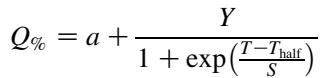

Image: 9870ada16acf50a06bf92087164c55ffd586020e5f56d6d809bf51bbf8a43a64.jpg


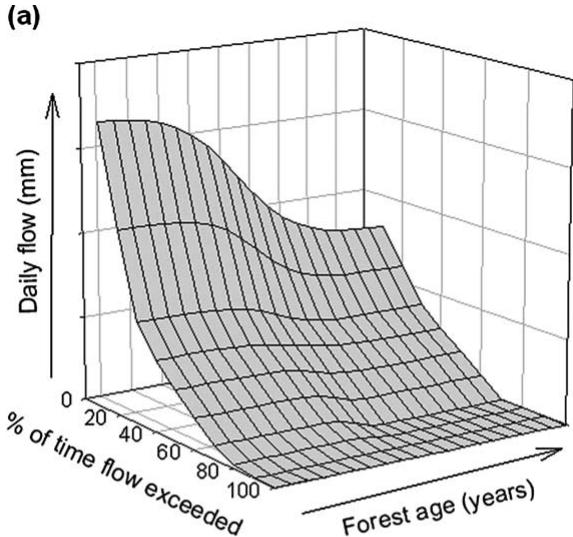

Image: 7aff67476d999509e9194eb7e031bb5f5486d98b69ea21d85ab2dfaba67d9186.jpg


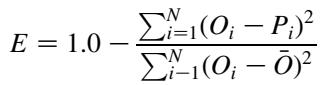

Image: 05d292272a8cbf6451e8812bee0b5e8874fc7e548ebb1420314580f801a8bdbc.jpg


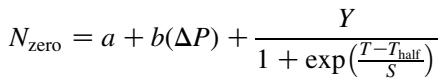


✅ Done. Change SAMPLE / backend / lang above to parse your own files.


In [1]:
install_mineru()
show_device()
SAMPLE = get_sample_pdf()
OUT = parse_pdf(SAMPLE, backend="pipeline", lang=None)
show_results(OUT)
print("\n✅ Done. Change SAMPLE / backend / lang above to parse your own files.")